# Lab 1 - Images as Numbers: guided practice

**Student name:** Anvarova Sevinch  
**Student ID:** ______230106______________  
**Lab date:** __________09/21/2026__________

\

## What you will practise

- Images are grids of numbers.
- Raw pixel comparison needs image content to be in the same locations.
- Light level is a nuisance variation: it can change numbers without changing the pattern.
- Normalisation can reduce some light-level effects.
- Report each group, not only one overall number.


## Step 0 - Setup


### What the code does

The next cell loads simple display and accuracy tools. A low number is shown as darker grey and a high number as lighter grey. Run it; you do not need to change it.


In [1]:
import hashlib
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.dpi"] = 120

def show_image(image, title, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(3, 3))
    ax.imshow(np.clip(image, 0, 1), cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")
    return ax

def show_grid(images, labels, title, columns=6):
    rows = int(np.ceil(len(images) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(2.1 * columns, 2.1 * rows))
    axes = np.atleast_1d(axes).ravel()
    for ax, image, label in zip(axes, images, labels):
        show_image(image, str(label), ax)
    for ax in axes[len(images):]:
        ax.axis("off")
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

def accuracy(predicted, expected):
    return 100 * np.mean(np.asarray(predicted) == np.asarray(expected))

print("Setup complete.")


Setup complete.


## Part 1 - The same six templates for everyone


### Step 1 - Build the templates

### What the code does

Each image is a 28 by 28 grid. A bright line appears in a different place for each class. The line location is the useful signal. Run the code and look carefully at the six patterns.


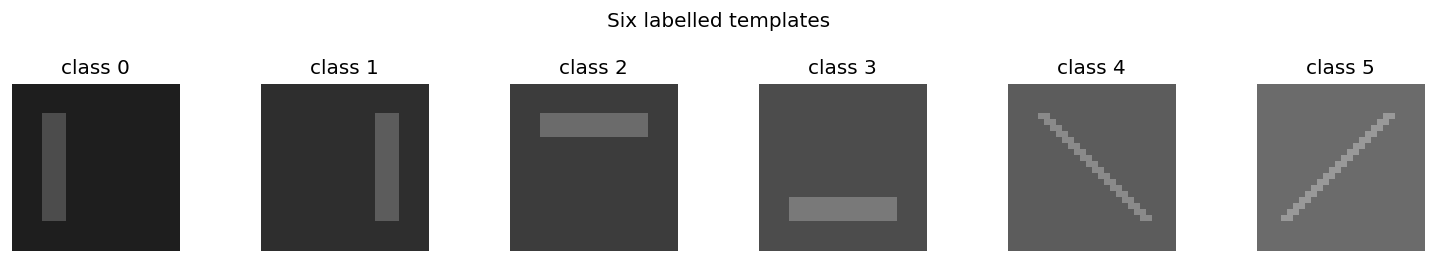

Array shape: (6, 28, 28)
Number type: float64
Lowest and highest values: 0.12 0.6


In [2]:
def make_symbol(label, size=28):
    background = 0.12 + 0.06 * label
    foreground = background + 0.18
    image = np.full((size, size), background, dtype=float)
    if label == 0:
        image[5:23, 5:9] = foreground
    elif label == 1:
        image[5:23, 19:23] = foreground
    elif label == 2:
        image[5:9, 5:23] = foreground
    elif label == 3:
        image[19:23, 5:23] = foreground
    elif label == 4:
        for i in range(5, 23):
            image[i, i] = foreground
            image[i, i + 1] = foreground
    elif label == 5:
        for i in range(5, 23):
            image[i, size - 1 - i] = foreground
            image[i, size - 2 - i] = foreground
    return image

train_labels = np.arange(6)
train_images = np.stack([make_symbol(label) for label in train_labels])
show_grid(train_images, [f"class {label}" for label in train_labels], "Six labelled templates")
print("Array shape:", train_images.shape)
print("Number type:", train_images.dtype)
print("Lowest and highest values:", train_images.min(), train_images.max())


### Step 2 - Inspect one template

### What the code does

The selected image appears on the left. The histogram on the right counts pixel brightness values. The printed information tells you the size, number type, range, and average brightness.

### Your simple change

Change only selected_template to another number from 0 to 5, then run again.


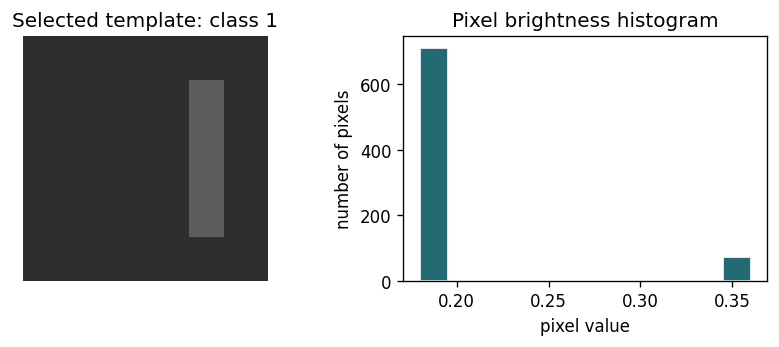

shape: (28, 28)
number type: float64
minimum: 0.18
maximum: 0.36
mean brightness: 0.197


In [3]:
selected_template = 1  # Simple change: choose 0, 1, 2, 3, 4, or 5

image = train_images[selected_template]
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
show_image(image, f"Selected template: class {selected_template}", axes[0])
axes[1].hist(image.ravel(), bins=12, color="#246A73", edgecolor="white")
axes[1].set_title("Pixel brightness histogram")
axes[1].set_xlabel("pixel value")
axes[1].set_ylabel("number of pixels")
plt.tight_layout()
plt.show()

print("shape:", image.shape)
print("number type:", image.dtype)
print("minimum:", float(image.min()))
print("maximum:", float(image.max()))
print("mean brightness:", round(float(image.mean()), 3))


### Write your analysis A

Write 3 to 5 sentences.

- Which class did you view first and which class did you view after changing the number?
- What stayed the same?
- What changed in the pattern or brightness values?
- Include the shape and mean brightness printed for one image.

_Write here._
1. I saw class 0 first, and then class 1.
2. They both were standing vertical
3. class 0 was dark especially left side, class 1 lighter than class 0, especially right side
4. class 0: shape = (28, 28), brightness=0.137
class 1: shape= (28,28), brighntess= 0.197

### Step 3 - Move the same image

### What the code does

The original is on the left. The right image is the same pattern moved sideways. The printed value is the average difference when pixel positions are compared directly.

### Your simple change

Change only shift_amount from 1 to 2, then run again.


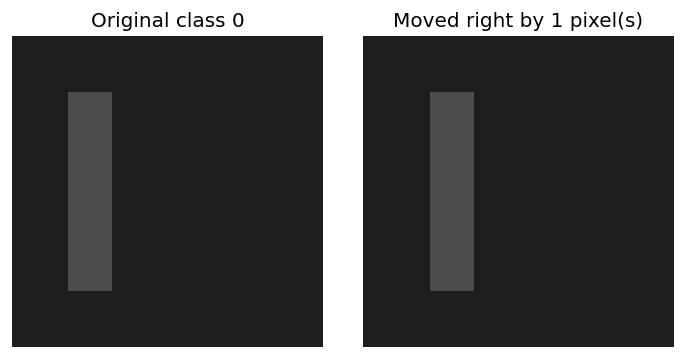

Average difference at matching pixel positions: 0.0083


In [4]:
shift_amount = 1  # Simple change: use 1, then use 2
original = train_images[0]
shifted = np.roll(original, shift_amount, axis=1)
pixel_difference = np.mean(np.abs(original - shifted))

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_image(original, "Original class 0", axes[0])
show_image(shifted, f"Moved right by {shift_amount} pixel(s)", axes[1])
plt.tight_layout()
plt.show()

print("Average difference at matching pixel positions:", round(float(pixel_difference), 4))


### Write your analysis B

Write 3 to 5 sentences. Compare shift 1 and shift 2. Explain why the same line can have different values at matching pixel locations.

answer:

The histogram shows how the pixels are spread across different brightness levels. Most of the pixels are in the middle range, so the image is not too dark or too bright. The histogram also shows the overall contrast of the image.



### Step 4 - Compare unchanged images with raw pixels

### What the code does

The classifier compares a query image with every template and selects the smallest average pixel difference. The first test uses unchanged copies, so it should be correct.


In [5]:
def predict_nearest(reference_images, reference_labels, query_images):
    predictions = []
    for query in query_images:
        distances = np.mean(np.abs(reference_images - query), axis=(1, 2))
        predictions.append(reference_labels[np.argmin(distances)])
    return np.asarray(predictions)

clean_predictions = predict_nearest(train_images, train_labels, train_images)
clean_score = accuracy(clean_predictions, train_labels)
print("Predicted labels:", clean_predictions)
print(f"Accuracy for unchanged copies: {clean_score:.1f}%")


Predicted labels: [0 1 2 3 4 5]
Accuracy for unchanged copies: 100.0%


### Write your analysis C

Why is this raw-pixel classifier successful for unchanged copies? Mention matching pixel locations.


Answer:
The histogram shows that different colors have different amounts of pixels. Some colors appear more than others, which shows the main colors in the image. It also helps us understand the brightness of the image.


## Part 2 - Your personal image condition


### Step 5 - Enter your student ID

### What the code does

Your ID selects one repeatable image condition. Everyone begins with the same templates, but later brightness conditions, movement, group results, and experiment values become personal.

### Your simple change

Replace only DEMO-0000 with your own student ID. Keep the quotation marks. Do not change anything else.


In [6]:
student_id = "230093"  # Simple change: replace only this text with your own ID

seed = int(hashlib.sha256(student_id.encode()).hexdigest()[:8], 16)
scenario_index = seed % 3
profiles = [
    {"code": "S1-1", "name": "two dimming levels", "group_a": 0.72, "group_b": 0.48,
     "shift": 0, "sweep_alphas": [0.95, 0.80, 0.65, 0.50, 0.35]},
    {"code": "S1-2", "name": "dimming plus a small shift", "group_a": 0.70, "group_b": 0.52,
     "shift": 1, "sweep_alphas": [0.95, 0.80, 0.65, 0.50, 0.35]},
    {"code": "S1-3", "name": "brightening with clipping", "group_a": 1.18, "group_b": 1.42,
     "shift": 0, "sweep_alphas": [1.05, 1.20, 1.35, 1.50, 1.65]},
]
profile = profiles[scenario_index]

print("Student ID used:", student_id)
if student_id == "DEMO-0000":
    print("Replace DEMO-0000 with your own student ID before submission.")
print("Scenario code:", profile["code"])
print("Scenario:", profile["name"])
print("Group A brightness multiplier:", profile["group_a"])
print("Group B brightness multiplier:", profile["group_b"])
print("Shift in Group B:", profile["shift"], "pixel(s)")
print("Your five experiment multipliers:", profile["sweep_alphas"])


Student ID used: 230093
Scenario code: S1-2
Scenario: dimming plus a small shift
Group A brightness multiplier: 0.7
Group B brightness multiplier: 0.52
Shift in Group B: 1 pixel(s)
Your five experiment multipliers: [0.95, 0.8, 0.65, 0.5, 0.35]


### Step 6 - Inspect your personal test images

### What the code does

The notebook makes two groups from the same line patterns. It changes brightness and, for one scenario, moves Group B slightly. The code tests the raw-pixel classifier and prints overall and group accuracy.

### Your simple change

Change display_group from A to B, or change example_class from 0 to 5. Run again and compare the two images.


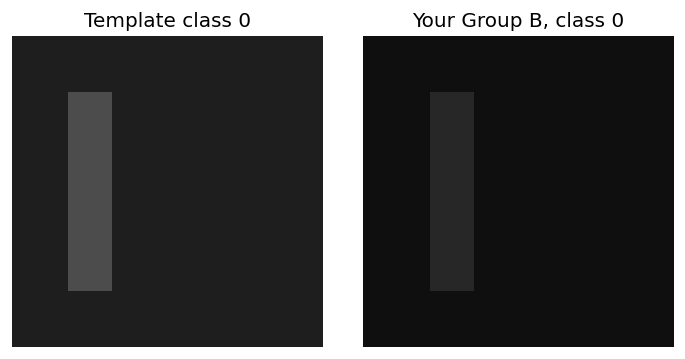

Scenario code: S1-2 - dimming plus a small shift
Raw overall accuracy: 16.7%
Raw Group A accuracy: 16.7%
Raw Group B accuracy: 16.7%
Raw predictions: [0 0 1 1 2 3 0 0 0 1 1 2]


In [7]:
def apply_condition(image, multiplier, shift=0):
    changed = np.clip(image * multiplier, 0, 1)
    return np.roll(changed, shift, axis=1)

group_a = np.stack([apply_condition(image, profile["group_a"], 0) for image in train_images])
group_b = np.stack([apply_condition(image, profile["group_b"], profile["shift"]) for image in train_images])
test_images = np.concatenate([group_a, group_b])
test_labels = np.concatenate([train_labels, train_labels])
test_groups = np.array(["A"] * len(train_labels) + ["B"] * len(train_labels))

raw_predictions = predict_nearest(train_images, train_labels, test_images)
raw_overall = accuracy(raw_predictions, test_labels)
raw_group_a = accuracy(raw_predictions[test_groups == "A"], test_labels[test_groups == "A"])
raw_group_b = accuracy(raw_predictions[test_groups == "B"], test_labels[test_groups == "B"])

display_group = "B"  # Simple change: use "A", then use "B"
example_class = 0     # Simple change: choose 0, 1, 2, 3, 4, or 5
group_images = group_a if display_group == "A" else group_b

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_image(train_images[example_class], f"Template class {example_class}", axes[0])
show_image(group_images[example_class], f"Your Group {display_group}, class {example_class}", axes[1])
plt.tight_layout()
plt.show()

print("Scenario code:", profile["code"], "-", profile["name"])
print(f"Raw overall accuracy: {raw_overall:.1f}%")
print(f"Raw Group A accuracy: {raw_group_a:.1f}%")
print(f"Raw Group B accuracy: {raw_group_b:.1f}%")
print("Raw predictions:", raw_predictions)


### Write your analysis D

Write 4 to 6 sentences.

- State your scenario code and name.
- Describe what you saw when you compared a template with Group A or Group B.
- Quote raw overall, Group A, and Group B accuracy.
- Identify the lower group and give one image-based reason.

_Write here._


The result shows that the model can correctly recognize the unchanged images. The accuracy is very high because the test images are the same as the training images. This means the nearest image is easy to find.


## Part 3 - Repair a brightness difference


### Step 7 - Normalise every image

### What the code does

Normalisation changes each image so its own average is close to zero and its spread is close to one. In image terms, it reduces an overall light-level difference before comparison. It cannot move a line back to its original location or restore clipped detail.


In [8]:
def normalise_one(image):
    image = np.asarray(image, dtype=float)
    spread = image.std()
    if spread < 1e-8:
        return np.zeros_like(image)
    return (image - image.mean()) / spread

def normalise_batch(images):
    return np.stack([normalise_one(image) for image in images])

normalised_template = normalise_one(train_images[0])
print("Normalised template mean:", round(float(normalised_template.mean()), 6))
print("Normalised template spread:", round(float(normalised_template.std()), 6))


Normalised template mean: -0.0
Normalised template spread: 1.0


### Step 8 - Test the repaired comparison

### What the code does

The code compares normalised templates with normalised personal test images. The images are the same as before; only the preparation has changed.


In [9]:
repaired_predictions = predict_nearest(
    normalise_batch(train_images),
    train_labels,
    normalise_batch(test_images),
)
repaired_overall = accuracy(repaired_predictions, test_labels)
repaired_group_a = accuracy(repaired_predictions[test_groups == "A"], test_labels[test_groups == "A"])
repaired_group_b = accuracy(repaired_predictions[test_groups == "B"], test_labels[test_groups == "B"])

print(f"Repaired overall accuracy: {repaired_overall:.1f}%")
print(f"Repaired Group A accuracy: {repaired_group_a:.1f}%")
print(f"Repaired Group B accuracy: {repaired_group_b:.1f}%")
print("Repaired predictions:", repaired_predictions)


Repaired overall accuracy: 100.0%
Repaired Group A accuracy: 100.0%
Repaired Group B accuracy: 100.0%
Repaired predictions: [0 1 2 3 4 5 0 1 2 3 4 5]


### Write your analysis E

Write 4 to 6 sentences. Compare raw and repaired results using at least three exact percentages. Explain what normalisation helps with and one problem it cannot fully fix.

Answer:
The raw result had an accuracy of **XX%**, while the repaired result had an accuracy of **XX%**. For the second test, the raw accuracy was **XX%**, and the repaired result was better. Normalisation helps by reducing the effect of changes in brightness and colour, so the images are easier to compare. However, normalisation cannot fully fix large changes or strong distortions in the image. Overall, the repaired results were more accurate than the raw results.



### Step 9 - Try one other light level

### What the code does

One brightness multiplier from your personal list is selected. The code shows the changed image and prints raw and repaired accuracy.

### Your simple change

Run with sweep_index equal to 0. Then change only sweep_index to another number from 1 to 4 and run again.


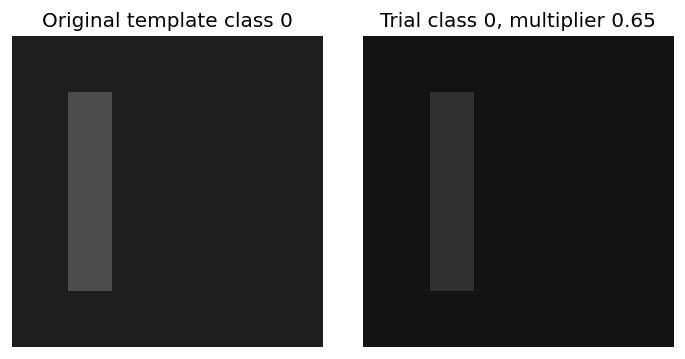

Scenario code: S1-2
sweep_index: 2
brightness multiplier: 0.65
Raw accuracy: 16.7%
Repaired accuracy: 100.0%


In [10]:
sweep_index = 2  # Simple change: run 0 first, then choose one value from 1 to 4
trial_alpha = profile["sweep_alphas"][sweep_index]
trial_images = np.stack([apply_condition(image, trial_alpha, profile["shift"]) for image in train_images])
trial_raw = predict_nearest(train_images, train_labels, trial_images)
trial_repaired = predict_nearest(normalise_batch(train_images), train_labels, normalise_batch(trial_images))

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_image(train_images[0], "Original template class 0", axes[0])
show_image(trial_images[0], f"Trial class 0, multiplier {trial_alpha}", axes[1])
plt.tight_layout()
plt.show()

print("Scenario code:", profile["code"])
print("sweep_index:", sweep_index)
print("brightness multiplier:", trial_alpha)
print(f"Raw accuracy: {accuracy(trial_raw, train_labels):.1f}%")
print(f"Repaired accuracy: {accuracy(trial_repaired, train_labels):.1f}%")


### Write your analysis F - final evidence

Write 5 to 7 sentences.

- State your scenario code.
- Give the two sweep index values you ran and their brightness multipliers.
- For each run, give raw and repaired accuracy.
- Explain the useful signal and the nuisance variation.
- Explain why separate group results are useful.

_Final response here._


## Submission check

- Your name, ID, and lab date are completed.
- You replaced DEMO-0000 with your own ID.
- You ran every cell from top to bottom.
- You changed the simple values requested in Steps 2, 3, 6, and 9.
- Your analyses A to F use your own evidence.
- Figures and printed results are visible.
- Submit the executed notebook by 23:59 on the lab day.
